In [17]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [19]:
# Load dataset
df = pd.read_csv(r"C:\Users\divya\OneDrive\Documents\Experiments\Exp-8\dataset\Groceries_dataset.csv")

# Show first rows
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [ ]:
# Check missing values
print(df.isnull().sum())

# Check columns
print(df.columns)

Member_number      0
Date               0
itemDescription    0
dtype: int64
Index(['Member_number', 'Date', 'itemDescription'], dtype='object')


In [ ]:
# Group items by transaction
transactions = df.groupby('Member_number')['itemDescription'].apply(list)

transactions.head()

Member_number
1000    [soda, canned beer, sausage, sausage, whole mi...
1001    [frankfurter, frankfurter, beef, sausage, whol...
1002    [tropical fruit, butter milk, butter, frozen v...
1003    [sausage, root vegetables, rolls/buns, deterge...
1004    [other vegetables, pip fruit, root vegetables,...
Name: itemDescription, dtype: object

In [ ]:
# Convert to one-hot encoding
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_data, columns=te.columns_)

df_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
# Generate frequent itemsets
frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)

frequent_itemsets.head()

,support,itemsets
0,0.078502,(UHT-milk)
1,0.031042,(baking powder)
2,0.119548,(beef)
3,0.079785,(berries)
4,0.062083,(beverages)


In [ ]:
# Generate rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(UHT-milk),(other vegetables),0.078502,0.376603,0.038994,0.496732,1.318979,1.0,0.009430,1.238697,0.262440,0.093711,0.192700,0.300137
1,(UHT-milk),(rolls/buns),0.078502,0.349666,0.031042,0.395425,1.130863,1.0,0.003592,1.075687,0.125578,0.078165,0.070361,0.242100
2,(UHT-milk),(soda),0.078502,0.313494,0.027450,0.349673,1.115406,1.0,0.002840,1.055632,0.112280,0.075299,0.052700,0.218617
3,(UHT-milk),(whole milk),0.078502,0.458184,0.040534,0.516340,1.126928,1.0,0.004565,1.120242,0.122227,0.081696,0.107336,0.302403
4,(beef),(other vegetables),0.119548,0.376603,0.050795,0.424893,1.128223,1.0,0.005773,1.083966,0.129082,0.114055,0.077462,0.279885


In [ ]:
# Filter strong rules
strong_rules = rules[rules['lift'] > 1]

strong_rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(UHT-milk),(other vegetables),0.078502,0.376603,0.038994,0.496732,1.318979,1.0,0.009430,1.238697,0.262440,0.093711,0.192700,0.300137
1,(UHT-milk),(rolls/buns),0.078502,0.349666,0.031042,0.395425,1.130863,1.0,0.003592,1.075687,0.125578,0.078165,0.070361,0.242100
2,(UHT-milk),(soda),0.078502,0.313494,0.027450,0.349673,1.115406,1.0,0.002840,1.055632,0.112280,0.075299,0.052700,0.218617
3,(UHT-milk),(whole milk),0.078502,0.458184,0.040534,0.516340,1.126928,1.0,0.004565,1.120242,0.122227,0.081696,0.107336,0.302403
4,(beef),(other vegetables),0.119548,0.376603,0.050795,0.424893,1.128223,1.0,0.005773,1.083966,0.129082,0.114055,0.077462,0.279885


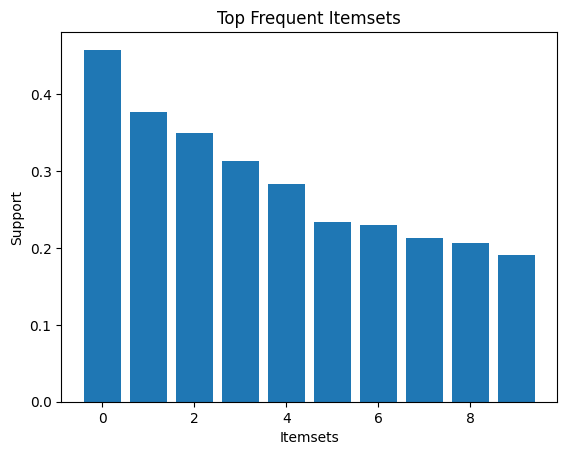

In [ ]:
# Top 10 frequent itemsets
top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.bar(range(len(top_items)), top_items['support'])
plt.title("Top Frequent Itemsets")
plt.xlabel("Itemsets")
plt.ylabel("Support")

plt.show()

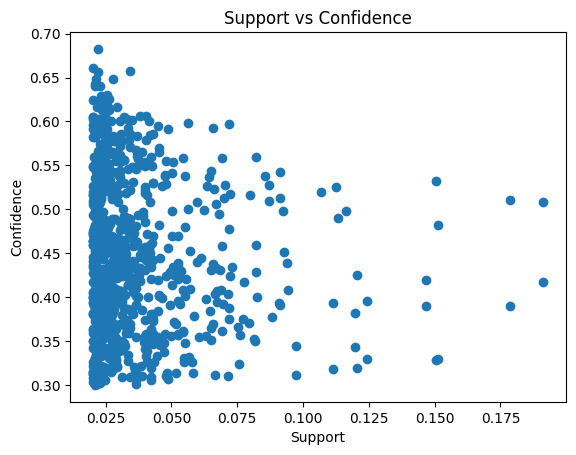

In [ ]:
# Scatter plot
plt.scatter(rules['support'], rules['confidence'])

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")

plt.show()

In [ ]:
# Show important columns
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

  antecedents         consequents   support  confidence      lift
0  (UHT-milk)  (other vegetables)  0.038994    0.496732  1.318979
1  (UHT-milk)        (rolls/buns)  0.031042    0.395425  1.130863
2  (UHT-milk)              (soda)  0.027450    0.349673  1.115406
3  (UHT-milk)        (whole milk)  0.040534    0.516340  1.126928
4      (beef)  (other vegetables)  0.050795    0.424893  1.128223
